Using device: cuda:0
Loading metadata...
Successfully loaded 25000 images across 5 classes: ['cephalophus nigrifrons', 'empty', 'aepyceros melampus', 'meleagris ocellata', 'crax rubra']

Epoch 1/5
Train Loss: 0.1288 Acc: 0.9545
Val Loss: 0.0414 Acc: 0.9848

Epoch 2/5
Train Loss: 0.0376 Acc: 0.9872
Val Loss: 0.0247 Acc: 0.9924

Epoch 3/5
Train Loss: 0.0232 Acc: 0.9920
Val Loss: 0.0311 Acc: 0.9894

Epoch 4/5
Train Loss: 0.0155 Acc: 0.9953
Val Loss: 0.0355 Acc: 0.9902

Epoch 5/5
Train Loss: 0.0168 Acc: 0.9947
Val Loss: 0.0194 Acc: 0.9936

Evaluating on Validation Set...

Validation Macro-F1 Score: 0.9942


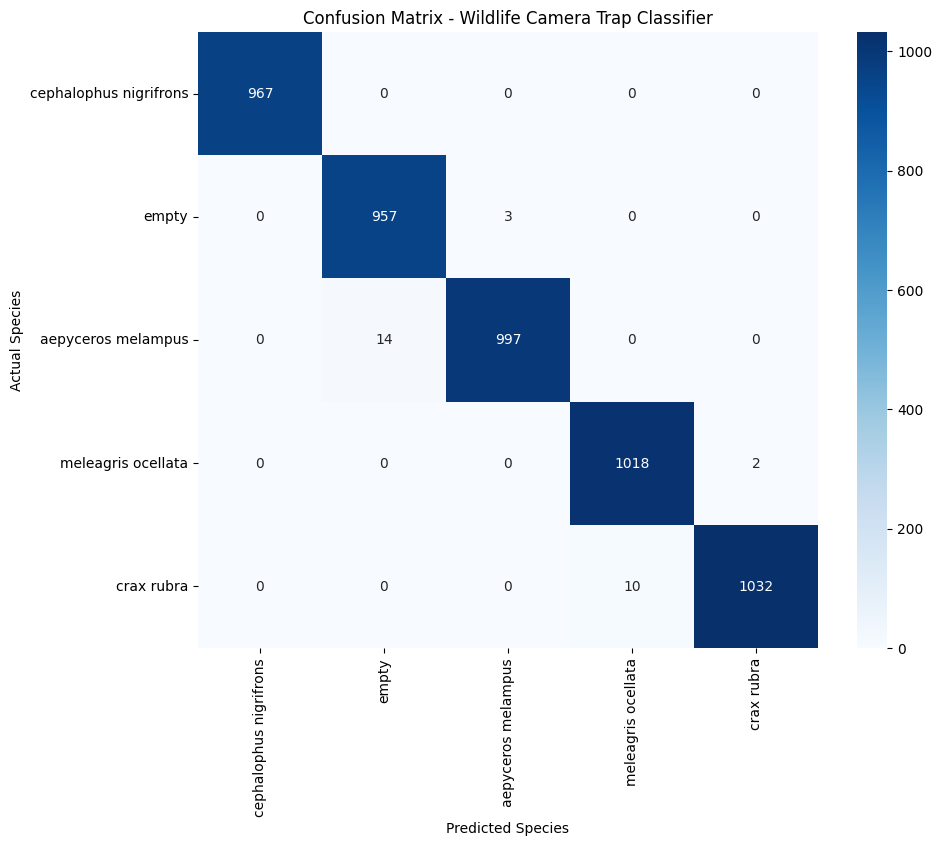

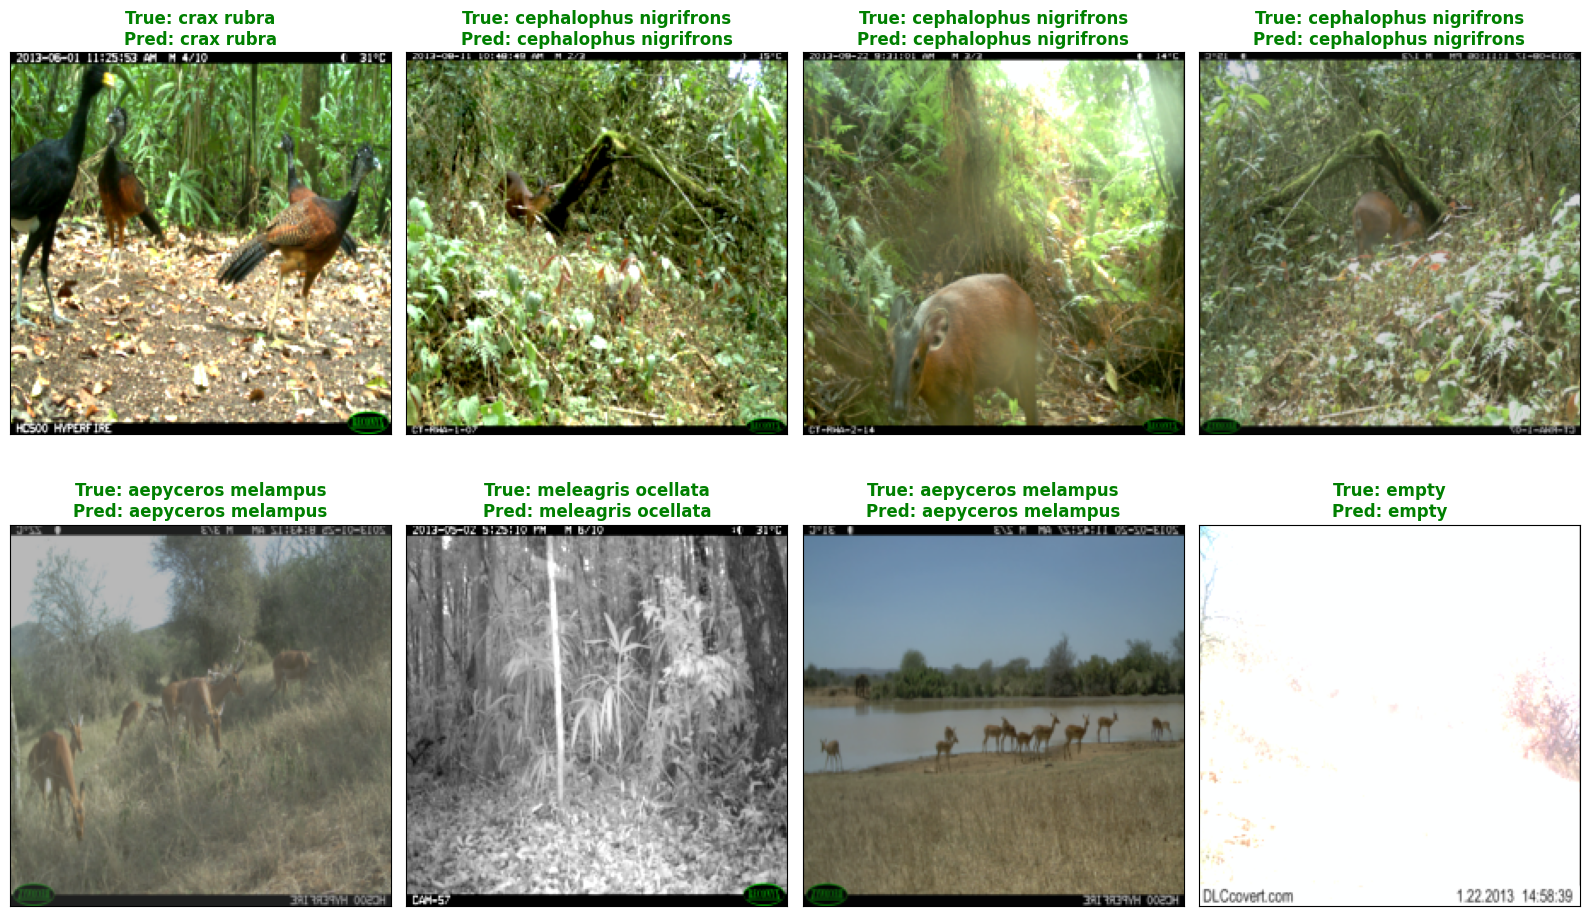

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from PIL import Image

# Setup Device
# This will confirm if you successfully turned on the Kaggle GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Parse iWildCam Metadata (Kaggle Paths)
# These paths are specific to the Kaggle environment's mounted data
# Updated Kaggle Paths
IMAGES_DIR = "/kaggle/input/competitions/iwildcam2022-fgvc9/train/train"
ANNOTATIONS_FILE = "/kaggle/input/competitions/iwildcam2022-fgvc9/metadata/metadata/iwildcam2022_train_annotations.json"

print("Loading metadata...")
with open(ANNOTATIONS_FILE, 'r') as f:
    train_meta = json.load(f)

df_images = pd.DataFrame(train_meta['images'])
df_annotations = pd.DataFrame(train_meta['annotations'])
df_categories = pd.DataFrame(train_meta['categories'])

# MVP: Keep only the top 5 most common species
top_5_classes = df_merged['category_id'].value_counts().nlargest(5).index

# Filter the dataset to only include those top 5 animals
df_final = df_merged[df_merged['category_id'].isin(top_5_classes)].reset_index(drop=True)

# Grab 5,000 images per class (25,000 total images)
df_final = df_final.groupby('category_id').head(5000).reset_index(drop=True)

unique_classes = df_final['category_id'].unique()
class_to_idx = {cat_id: idx for idx, cat_id in enumerate(unique_classes)}
df_final['label'] = df_final['category_id'].map(class_to_idx)

# MVP- Keep only the top 5 most common species so it trains before Thursday
top_5_classes = df_merged['category_id'].value_counts().nlargest(5).index

unique_classes = df_final['category_id'].unique()
class_to_idx = {cat_id: idx for idx, cat_id in enumerate(unique_classes)}
df_final['label'] = df_final['category_id'].map(class_to_idx)

# Map category names for the confusion matrix later
category_dict = dict(zip(df_categories['id'], df_categories['name']))
class_names = [category_dict[cat_id] for cat_id in unique_classes]

print(f"Successfully loaded {len(df_final)} images across 5 classes: {class_names}")

# 3. Custom PyTorch Dataset
class IWildCamDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['file_name']
        img_path = os.path.join(self.img_dir, img_name)
        
        image = Image.open(img_path).convert('RGB')
        label = self.dataframe.iloc[idx]['label']

        if self.transform:
            image = self.transform(image)

        return image, label

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.5, contrast=0.5), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Data Loading & Class Imbalance Handling
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

train_size = int(0.8 * len(df_final))
df_train = df_final.iloc[:train_size].reset_index(drop=True)
df_val = df_final.iloc[train_size:].reset_index(drop=True)

train_dataset = IWildCamDataset(df_train, IMAGES_DIR, transform=data_transforms)
val_dataset = IWildCamDataset(df_val, IMAGES_DIR, transform=data_transforms)

class_counts = df_train['label'].value_counts().sort_index().values
class_weights = 1. / class_counts
sample_weights = np.array([class_weights[t] for t in df_train['label']])
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)


dataloaders = {
    'train': DataLoader(
        train_dataset, 
        batch_size=64, 
        sampler=sampler, 
        num_workers=2,         # Leave cores for the main thread
        pin_memory=True,       # Enable direct memory access to the GPU
        prefetch_factor=2      # Tell workers to queue up 2 batches in advance
    ),
    'val': DataLoader(
        val_dataset, 
        batch_size=64, 
        shuffle=False, 
        num_workers=2, 
        pin_memory=True
    )
}

# Model Setup & Training Loop
model = models.resnet18(weights='IMAGENET1K_V1')
for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(unique_classes)) 
model = model.to(device)

# Unfreeze the last convolutional block so it learns animal features
for param in model.layer4.parameters():
    param.requires_grad = True

# Update the optimizer to include these newly unfrozen parameters
optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-4}, 
    {'params': model.fc.parameters(), 'lr': 1e-3}
])

# Convert your existing class_weights numpy array to a PyTorch tensor
weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

num_epochs = 5 

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  
        else:
            model.eval()   

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloaders[phase].dataset)
        epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)
        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

# Evaluation for the Blog
print("\nEvaluating on Validation Set...")
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

macro_f1 = f1_score(all_labels, all_preds, average='macro')
print(f"\nValidation Macro-F1 Score: {macro_f1:.4f}")

cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(class_names))))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual Species')
plt.xlabel('Predicted Species')
plt.title('Confusion Matrix - Wildlife Camera Trap Classifier')
plt.show()


# Visualizing More Predictions (8 Images)
# Grab a batch of images from the validation set
inputs, labels = next(iter(dataloaders['val']))
inputs, labels = inputs.to(device), labels.to(device)

# Ask the model to predict
model.eval()
with torch.no_grad():
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)

# Plot 8 images in a 2x4 grid
fig = plt.figure(figsize=(16, 10)) # Made the canvas taller to fit two rows
for i in range(8): # Increased loop from 4 to 8
    # Changed subplot to (2 rows, 4 columns)
    ax = fig.add_subplot(2, 4, i+1, xticks=[], yticks=[])
    
    # Un-normalize the colors
    img = inputs[i].cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1) 
    
    ax.imshow(img)
    
    # Label the image (Green if correct, Red if wrong)
    true_name = class_names[labels[i]]
    pred_name = class_names[preds[i]]
    color = "green" if preds[i] == labels[i] else "red"
    
    ax.set_title(f"True: {true_name}\nPred: {pred_name}", color=color, fontweight='bold')

plt.tight_layout()
plt.show()